``aap.plot_eval`` turns the per-configuration sweep table (``df_eval``) of an ``aap.find_features`` run into a ``viridis`` **evaluation grid** so the CPP AutoML optimization is no longer a black box. The plot **adapts to how many levers actually varied**: a single configuration draws nothing (returns ``None``), one swept lever draws a line or bar, two draw a single heatmap, and three or more draw faceted small-multiples (one heatmap panel per level of the extra axes). Color encodes the cross-validated score (the selection metric) and the selected configuration is marked with a star. ``find_features`` draws this grid automatically as an auxiliary figure when ``plot=True``; here we call it directly on a ``df_eval`` table.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
import aaanalysis.pipe as aap

aa.options["verbose"] = False
aa.plot_settings()

df_seq = aa.load_dataset(name="DOM_GSEC", n=20)
labels = df_seq["label"].to_list()

# A real (small) balanced sweep: the Split levers vary, so df_eval has several configurations.
df_feat, ax, df_eval = aap.find_features(labels=labels, df_seq=df_seq, optimization="balanced",
                                         kws={"n_filter": 25, "n_explain": 20}, plot=False,
                                         random_state=42, n_jobs=1)

aa.display_df(df_eval, n_rows=10, show_shape=True)

DataFrame shape: (8, 11)


,list_parts,split_types,pattern_mode,n_split_max,n_explain,n_filter,n_features,cv_bacc_mean,cv_bacc_std,rank,is_selected
1,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,10,20,25,25,0.950000,0.100000,1,True
2,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern",p1,15,20,25,25,0.950000,0.100000,2,False
3,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,10,20,25,25,0.950000,0.061237,3,False
4,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,Pattern...PeriodicPattern",p1+p2,15,20,25,25,0.950000,0.061237,4,False
5,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,PeriodicPattern",p2,10,20,25,25,0.900000,0.145774,5,False
6,"tmd,jmd_n_tmd_n,tmd_c_jmd_c","Segment,PeriodicPattern",p2,15,20,25,25,0.900000,0.145774,6,False
7,"tmd,jmd_n_tmd_n,tmd_c_jmd_c",Segment,none,10,20,25,25,0.875000,0.079057,7,False
8,"tmd,jmd_n_tmd_n,tmd_c_jmd_c",Segment,none,15,20,25,25,0.875000,0.079057,8,False


Calling ``plot_eval`` on this table draws a heatmap (two levers varied) colored by the cross-validated score, with the selected configuration starred. ``title`` overrides the default heading; ``score_col`` names the score column to color by (default ``"cv_bacc_mean"``). ``plot_eval`` figures self-manage their layout (constrained layout + colorbar), so the plot cell ends with ``plt.show()`` only.

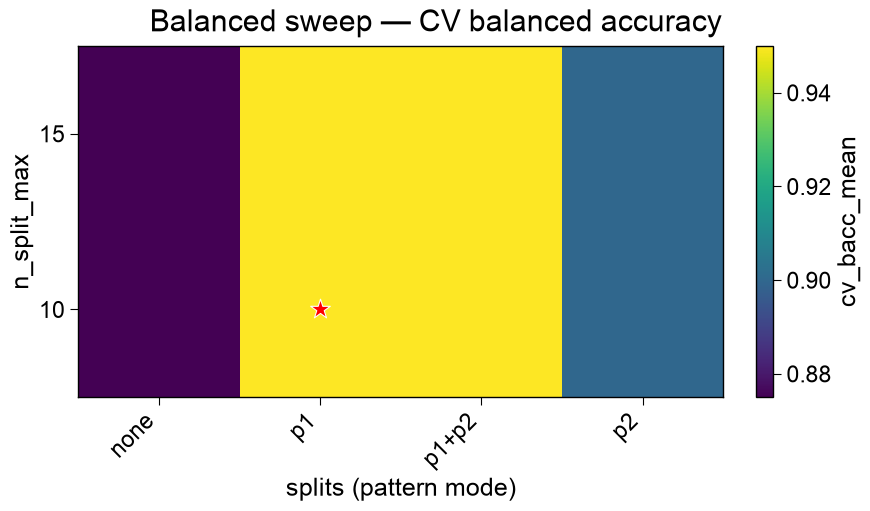

In [2]:
fig = aap.plot_eval(df_eval, score_col="cv_bacc_mean", title="Balanced sweep — CV balanced accuracy")

plt.show()

When only **one** lever varies, the grid is a line (numeric lever) with the per-configuration spread as error bars from ``std_col``, the points colored by the score. ``figsize`` sets the figure size, and ``dict_refine`` annotates the simplify / RFE refinement as a before → after Δ-score line (the two boolean refinement steps are shown as Δ-scores, not heatmap axes). Here we build a small ``df_eval`` over ``n_filter`` to show these options.

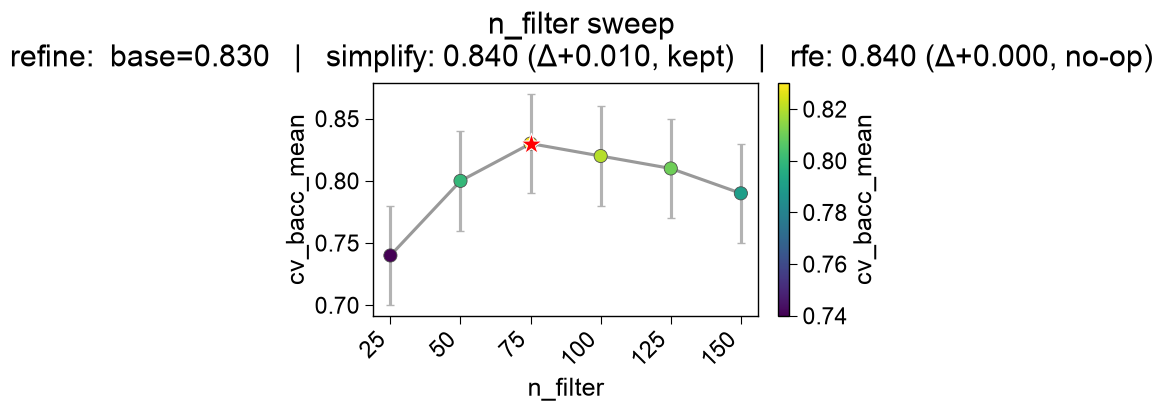

In [3]:
n_filters = [25, 50, 75, 100, 125, 150]
scores = [0.74, 0.80, 0.83, 0.82, 0.81, 0.79]
df_eval_1d = pd.DataFrame({
    "list_parts": "tmd", "split_types": "Segment", "pattern_mode": "none",
    "n_split_max": 15, "n_explain": 50, "n_filter": n_filters, "n_features": n_filters,
    "cv_bacc_mean": scores, "cv_bacc_std": 0.04,
})
df_eval_1d["rank"] = df_eval_1d["cv_bacc_mean"].rank(ascending=False).astype(int)
df_eval_1d["is_selected"] = df_eval_1d["cv_bacc_mean"] == df_eval_1d["cv_bacc_mean"].max()

dict_refine = {"base": 0.83, "simplify": 0.84, "simplify_kept": True, "rfe": 0.84, "rfe_kept": False}
fig = aap.plot_eval(df_eval_1d, std_col="cv_bacc_std", figsize=(6, 4), dict_refine=dict_refine,
                    title="n_filter sweep")

plt.show()